****INTRODUCTION****

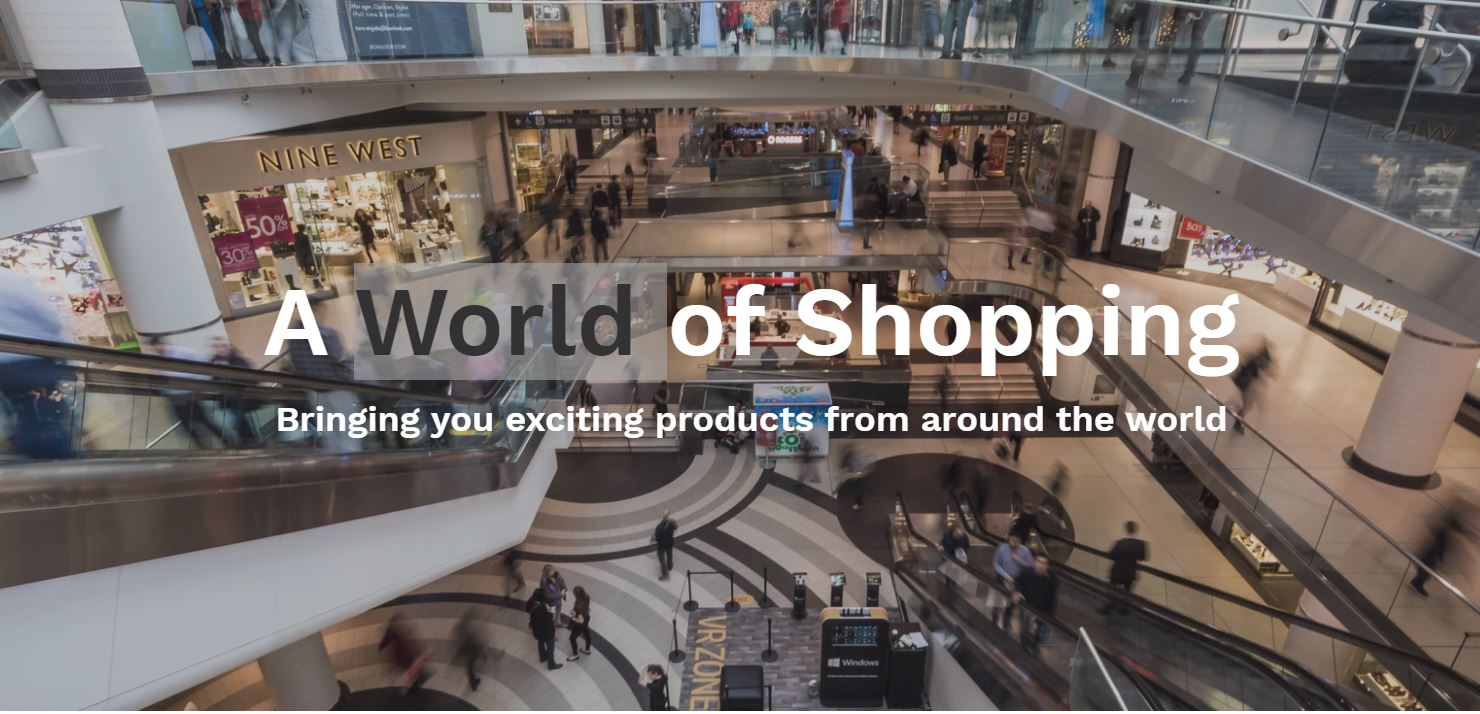

Online shopping has grown in popularity over the years, mainly because people find it convenient and easy to bargain shop from the comfort of their home or office. 

One of the most enticing factor about online shopping, particularly during a holiday season, is it alleviates the need to wait in long lines or search from store to store for a particular item.

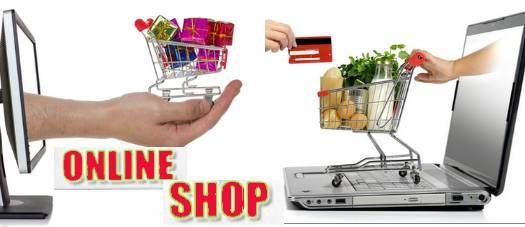

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

Lets look at the data of a superstore in US and get some insights from it.

****IMPORTING LIBRARIES****


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder

****READING THE DATA****

Lets us read the data and take a look at first few rows.

In [ ]:
df=pd.read_excel('/kaggle/input/superstore/US Superstore data.xls')
df.head()

**EXPLORATORY DATA ANALYSIS**

In [ ]:
#row,column count of data
df.shape

In [ ]:
#column names of table
df.columns

In [ ]:
#check data type of columns/attributes
df.dtypes

Lets check if there are any missing values in the data

In [ ]:
df.isnull().sum()

There are no missing values. Hence we can go exploratory analysis part directly.

**WAIT**.... Check for unnecessary columns and drop them if not required

'Row ID' column is nothing but the serial number so we can drop this column.

In [ ]:
#Dropping  Row ID column and assigning to df
df=df.drop('Row ID',axis=1)
df.head()

In [ ]:
df['Country'].value_counts()

Clearly the data is for US country only, so we can drop the 'Country' column as we dont need any analysis to be done based on it.

In [ ]:
#dropping Country column
df=df.drop('Country',axis=1)
df.head()

We can analyse the data further in 3 different ways

> * PRODUCT LEVEL ANALYSIS
> * CUSTOMER LEVEL ANALYSIS
> * ORDER LEVEL ANALYSIS

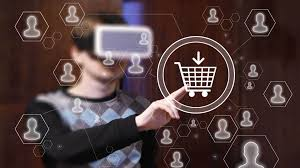

Lets look at the product categories available to shop for customers

In [ ]:
df['Category'].unique()

In [ ]:
#number of products in each category 
df['Category'].value_counts()

In [ ]:
#number of Sub-categories products are divided.
df['Sub-Category'].nunique()

In [ ]:
#number of products in each sub-category
df['Sub-Category'].value_counts()

In [ ]:
#Lets see how sub-categories are distributed wrt to category
plt.figure(figsize=(16,8))
plt.bar('Sub-Category','Category',data=df,color='y')
plt.show()

From this graph, one can easily makeout which Category & Sub-Category to choose when they are looking to purchase a product

In [ ]:
plt.figure(figsize=(12,10))
df['Sub-Category'].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

 The store has wide variety of Office Supplies especially in Binders and Paper department.

In [ ]:
df.groupby('Sub-Category')['Profit','Sales'].agg(['sum']).plot.bar()
plt.title('Total Profit and Sales per Sub-Category')
# plt.legend('Profit')
# plt.legend('Sales')
plt.show()

Highest profit is earned in Copiers while Selling price for Chairs and Phones is extremely high compared to other products.

Another interesting fact- people dont prefer to buy Tables and Bookcases from Superstore. Hence these departments are in loss.

In [ ]:
#number of products available in store
df['Product Name'].nunique()

In [ ]:
df['Product Name'].value_counts()

In [ ]:
#Distribution of Top 10 Products
plt.figure(figsize=(12,10))
df['Product Name'].value_counts().head(10).plot.pie(autopct="%1.1f%%")

In [ ]:
#Count of Sub-Category region wise
plt.figure(figsize=(15,8))
sns.countplot(x="Sub-Category", hue="Region", data=df)
plt.show()

People residing in Western part of US tend to order more from superstore.

To understand the data better. Lets create some new columns like Cost,Profit%

In [ ]:
df['Cost']=df['Sales']-df['Profit']
df['Cost'].head()

In [ ]:
df['Profit %']=(df['Profit']/df['Cost'])*100

In [ ]:
#Profit Percentage of first 5 product names
df.iloc[[0,1,2,3,4],[14,20]]

In [ ]:
#Products with high Profit Percentage 
df.sort_values(['Profit %','Product Name'],ascending=False).groupby('Profit %').head(5)

Retailers selling Phone,Binders,Papers have got 100% Profit in their Business.

**LETS LOOK AT THE DATA WRT TO CUSTOMER LEVEL**

In [ ]:
df['Customer ID'].nunique()

In [ ]:
#Top 10 customers who order frequently
df_top10=df['Customer Name'].value_counts().head(10)
df_top10

In [ ]:
fig=plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
s=sns.countplot('Segment', data = df)
for s in ax.patches:
    ax.annotate('{:.0f}'.format(s.get_height()), (s.get_x()+0.15, s.get_height()+1))
plt.show()

The distribution is highest in Consumer Segment.

In [ ]:
#Top 20 Customers who benefitted the store
sortedTop20 = df.sort_values(['Profit'], ascending=False).head(20)
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)
p = sns.barplot(x='Customer Name', y='Profit',hue='State',palette='Set1', data=sortedTop20, ax=ax)
ax.set_title("Top 20 profitable Customers")
ax.set_xticklabels(p.get_xticklabels(), rotation=75)
plt.tight_layout()
plt.show()

 We see that majority of the Profitable Customers are from New York and Michigan State.

Lets do some do some Analysis with Order details of the data

In [ ]:
#number of unique orders
df['Order ID'].nunique()

In [ ]:
#Calculating the time taken for an order to ship and converting the no. of days in int format
df['Shipment Duration']=(pd.to_datetime(df['Ship Date'])-pd.to_datetime(df['Order Date'])).dt.days
df['Shipment Duration']

In [ ]:
df.iloc[:,[0,3,21]]

Lets find out some more details about each Customer like total products purchased,Products they purchase,First Purchase Date,Last Purchase Date,Location from where the Customer placed an order.

In [ ]:
#creating function and appending customer and order info to it.
def agg_customer(x):
    d = []
    d.append(x['Order ID'].count())
    d.append(x['Sales'].sum())
    d.append(x['Profit %'].mean())
    d.append(pd.to_datetime(x['Order Date']).min())
    d.append(pd.to_datetime(x['Order Date']).max())
    d.append(x['Product Name'].unique())
    d.append(x['City'].unique())
    return pd.Series(d, index=['#Purchases','Total_Sales','Average Profit % gained','First_Purchase_Date','Latest_Purchase_Date','Products Purchased','Location_Count'])

In [ ]:
#grouping based on Customer ID and applying the function we created above
df_agg = df.groupby('Customer ID').apply(agg_customer)
df_agg

In [ ]:
#extracting the year of order
df['order year']=df['Order Date'].dt.year
df['order year'].head()

In [ ]:
#Calculating Profit gained in each Category
fig=plt.figure(figsize=(16,8))
ax = fig.add_subplot(111)
sns.barplot('order year','Profit %',hue='Sub-Category',palette='Paired',data=df)
for o in ax.patches:
    ax.annotate('{:.0f}'.format(o.get_height()), (o.get_x()+0.15, o.get_height()+1))
plt.show()

In [ ]:
#Sales per year
df.groupby('order year')['Sales','Profit %'].agg(['sum']).plot.bar()
plt.title('Year wise Total Sales & % of profit gained')

Sales of the store has increased every year resulting in high profit margin by the end of 2017.